In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
import pandas as pd

df = pd.read_csv("encoded_thyroid_2.csv")

df.columns

Index(['Age', 'Family_History', 'Radiation_Exposure', 'Iodine_Deficiency',
       'Smoking', 'Obesity', 'Diabetes', 'TSH_Level', 'T3_Level', 'T4_Level',
       'Nodule_Size', 'Thyroid_Cancer_Risk', 'Gender_Male',
       'Diagnosis_Malignant'],
      dtype='object')

##### **Checking Class Imbalance**

C:\Users\Hp\AppData\Local\Temp\ipykernel_8516\4176379302.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x='Diagnosis_Malignant', data=df, palette='pastel')


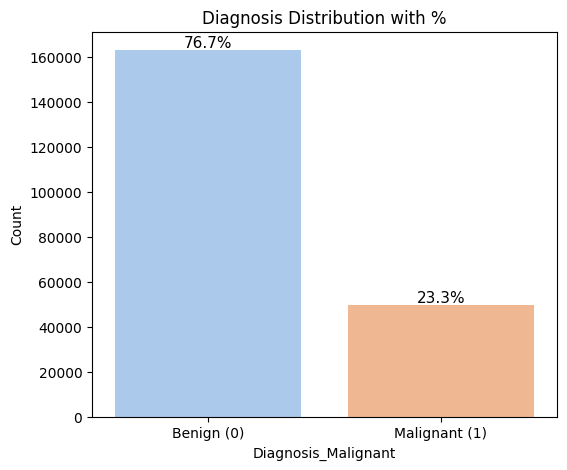

In [3]:
total = len(df)

plt.figure(figsize=(6,5))
ax = sns.countplot(x='Diagnosis_Malignant', data=df, palette='pastel')

# Add percentage labels on top of bars
for p in ax.patches:
    count = p.get_height() # type: ignore
    percentage = 100 * count / total
    ax.annotate(f'{percentage:.1f}%', (p.get_x() + p.get_width()/2., count), # type: ignore
                ha='center', va='bottom', fontsize=11, color='black')

plt.title('Diagnosis Distribution with %')
plt.xlabel('Diagnosis_Malignant')
plt.ylabel('Count')
plt.xticks([0,1], ['Benign (0)', 'Malignant (1)'])
plt.show()

### **Machine Learning**

In [4]:
from sklearn.model_selection import train_test_split  #Will be used For splitting.....
from imblearn.over_sampling import SMOTE
from collections import Counter
from sklearn.linear_model import LogisticRegression  
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
from sklearn.metrics import precision_recall_fscore_support
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.svm import SVC

In [5]:
df2=pd.read_csv("encoded_thyroid_2.csv")
df2.columns

Index(['Age', 'Family_History', 'Radiation_Exposure', 'Iodine_Deficiency',
       'Smoking', 'Obesity', 'Diabetes', 'TSH_Level', 'T3_Level', 'T4_Level',
       'Nodule_Size', 'Thyroid_Cancer_Risk', 'Gender_Male',
       'Diagnosis_Malignant'],
      dtype='object')

#### **Input and Target Columns**

In [6]:
Y=df2['Diagnosis_Malignant']
print(Y.head())
X=df2.drop(['Diagnosis_Malignant'],axis=1)
print(X.head())

0    0.0
1    0.0
2    0.0
3    0.0
4    0.0
Name: Diagnosis_Malignant, dtype: float64
   Age  Family_History  Radiation_Exposure  Iodine_Deficiency  Smoking  \
0   66               0                   1                  0        0   
1   29               0                   1                  0        0   
2   86               0                   0                  0        0   
3   75               0                   0                  0        0   
4   35               1                   1                  0        0   

   Obesity  Diabetes  TSH_Level  T3_Level  T4_Level  Nodule_Size  \
0        0         0       9.37      1.67      6.16         1.08   
1        0         0       1.83      1.73     10.54         4.05   
2        0         0       6.26      2.59     10.57         4.61   
3        0         0       4.10      2.62     11.04         2.46   
4        0         0       9.10      2.11     10.71         2.11   

   Thyroid_Cancer_Risk  Gender_Male  
0                    

### **Training & Testing Split**

In [7]:
#train_test_split returns 4 arrays so we take 4 variables , X_train, X_test, Y_train, Y_test
X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y, 
    test_size=0.2,       #20%
    random_state=42,     #reproducability  
    stratify=Y
)

#### **Target Distribution Verification**

In [8]:
print("Training set distribution:")
print(Y_train.value_counts(normalize=True) * 100)

print("\nTesting set distribution:")
print(Y_test.value_counts(normalize=True) * 100)

Training set distribution:
Diagnosis_Malignant
0.0    76.729042
1.0    23.270958
Name: proportion, dtype: float64

Testing set distribution:
Diagnosis_Malignant
0.0    76.729589
1.0    23.270411
Name: proportion, dtype: float64


### **Model Training**

#### **Prediction / Inference Phase**

#### Logistic Regression

In [10]:
log_reg_model = LogisticRegression(max_iter=1000)  
log_reg_model.fit(X_train, Y_train) 

LogisticRegression(max_iter=1000)

In [11]:
y_pred = log_reg_model.predict(X_test)
print("Predictions:", y_pred[:40])
print("Actual:", Y_test[:40].values)


Predictions: [0. 0. 1. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 1. 0. 0. 0.]
Actual: [1. 0. 1. 0. 1. 0. 1. 0. 0. 1. 0. 0. 1. 0. 0. 1. 1. 0. 0. 0. 0. 1. 1. 0.
 0. 0. 0. 0. 0. 0. 0. 1. 0. 1. 0. 0. 0. 0. 0. 0.]


#### **Accuracy Measurment**

In [12]:
accuracy = accuracy_score(Y_test, y_pred)
conf_matrix = confusion_matrix(Y_test, y_pred)
print(f"Accuracy: {accuracy}")
print(f"Confusion Matrix:\n{conf_matrix }")

Accuracy: 0.8293095747431769
Confusion Matrix:
[[30767  1873]
 [ 5388  4511]]


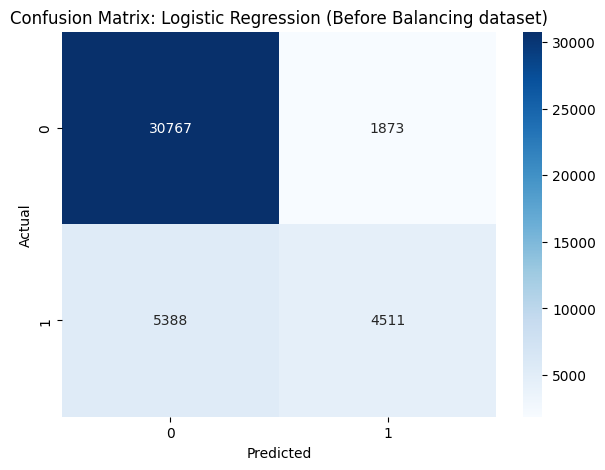

In [13]:
plt.figure(figsize=(7,5))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=[0,1], yticklabels=[0,1]) # type: ignore
plt.title('Confusion Matrix: Logistic Regression (Before Balancing dataset)')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [14]:
# Compute per-class metrics
precision, recall, f1, support = precision_recall_fscore_support(Y_test, y_pred, labels=[0,1])


metrics_df = pd.DataFrame({
    'Class': ['Benign (0)', 'Malignant (1)'],
    'Precision': precision,
    'Recall': recall,
    'F1-score': f1,
    'Support': support
})
metrics_df

,Class,Precision,Recall,F1-score,Support
0,Benign (0),0.850975,0.942616,0.894455,32640
1,Malignant (1),0.706610,0.455703,0.554075,9899


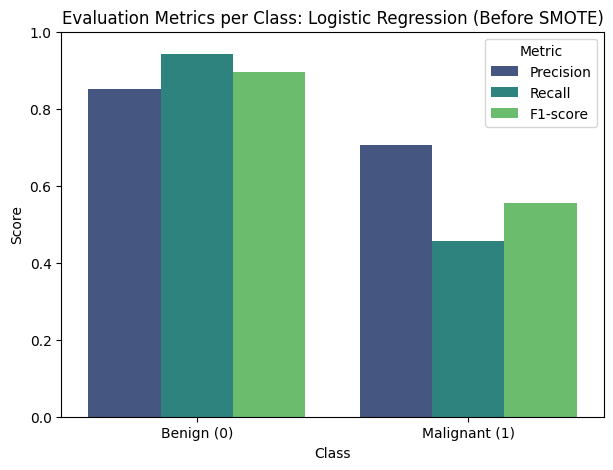

In [15]:
metrics_melted = metrics_df.melt(id_vars='Class', value_vars=['Precision','Recall','F1-score'],
                                 var_name='Metric', value_name='Score')

plt.figure(figsize=(7,5))
sns.barplot(x='Class', y='Score', hue='Metric', data=metrics_melted, palette='viridis')
plt.ylim(0,1)
plt.title('Evaluation Metrics per Class: Logistic Regression (Before SMOTE)')
plt.legend(title='Metric')
plt.show()



In [16]:
accuracies = {
    'Logistic Regression': 0.825,  
    'Decision Tree': 0.70,         
    'Random Forest': 0.712,        
    'XGBoost': 0.828               
}

# Convert to DataFrame
acc_df = pd.DataFrame(list(accuracies.items()), columns=['Algorithm','Accuracy'])
acc_df

,Algorithm,Accuracy
0,Logistic Regression,0.825
1,Decision Tree,0.700
2,Random Forest,0.712
3,XGBoost,0.828


#### **Decision Tree**

In [17]:
dt_model = DecisionTreeClassifier(random_state=42, class_weight='balanced')  # handle imbalance
dt_model.fit(X_train, Y_train)
y_pred = dt_model.predict(X_test)

print("Accuracy:", accuracy_score(Y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(Y_test, y_pred))
print(classification_report(Y_test, y_pred))

Accuracy: 0.712616657655328
Confusion Matrix:
 [[26545  6095]
 [ 6130  3769]]
              precision    recall  f1-score   support

         0.0       0.81      0.81      0.81     32640
         1.0       0.38      0.38      0.38      9899

    accuracy                           0.71     42539
   macro avg       0.60      0.60      0.60     42539
weighted avg       0.71      0.71      0.71     42539



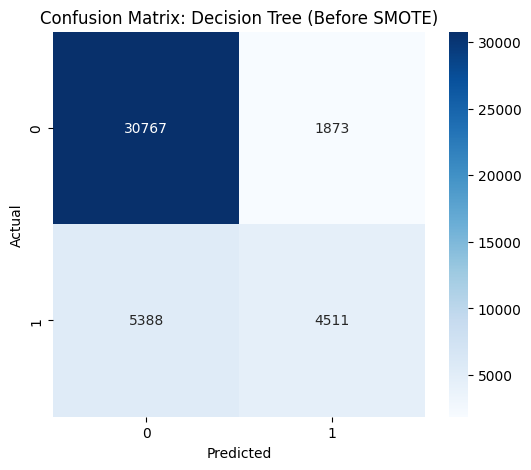

In [18]:
# Visualize the confusion matrix
plt.figure(figsize=(6,5))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=[0,1], yticklabels=[0,1]) # type: ignore
plt.title('Confusion Matrix: Decision Tree (Before SMOTE)')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

### XGBOOST

In [19]:
xgb_model = XGBClassifier(
    random_state=42,
    scale_pos_weight=2,
    use_label_encoder=False,
    eval_metric='logloss'
)
xgb_model.fit(X_train, Y_train)

# 3. Predict
y_pred_xgb = xgb_model.predict(X_test)

# 4. Evaluate
print("XGBoost Results")
print("Accuracy:", accuracy_score(Y_test, y_pred_xgb))
print("\nClassification Report:\n", classification_report(Y_test, y_pred_xgb))
print("Confusion Matrix:\n", confusion_matrix(Y_test, y_pred_xgb))

C:\Users\Hp\AppData\Roaming\Python\Python312\site-packages\xgboost\training.py:183: UserWarning: [12:00:18] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBoost Results
Accuracy: 0.8275464867533322

Classification Report:
               precision    recall  f1-score   support

         0.0       0.85      0.94      0.89     32640
         1.0       0.70      0.46      0.55      9899

    accuracy                           0.83     42539
   macro avg       0.77      0.70      0.72     42539
weighted avg       0.82      0.83      0.81     42539

Confusion Matrix:
 [[30690  1950]
 [ 5386  4513]]


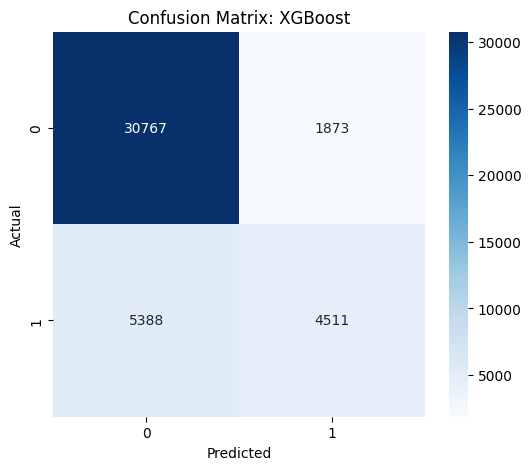

In [20]:
plt.figure(figsize=(6,5))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=[0,1], yticklabels=[0,1])
plt.title('Confusion Matrix: XGBoost')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

### Random Forest

In [21]:
# ----------------- Initialize Random Forest -----------------
rf_model = RandomForestClassifier(
    n_estimators=100,            # number of trees
    random_state=42,
    class_weight='balanced'      # handle class imbalance
)

# ----------------- Train -----------------
rf_model.fit(X_train, Y_train)

# ----------------- Predict -----------------
y_pred_rf = rf_model.predict(X_test)

# ----------------- Evaluate -----------------
print("Accuracy:", accuracy_score(Y_test, y_pred_rf))
print("Confusion Matrix:\n", confusion_matrix(Y_test, y_pred_rf))
print("\nClassification Report:\n", classification_report(Y_test, y_pred_rf))

Accuracy: 0.8261360163614565
Confusion Matrix:
 [[30848  1792]
 [ 5604  4295]]

Classification Report:
               precision    recall  f1-score   support

         0.0       0.85      0.95      0.89     32640
         1.0       0.71      0.43      0.54      9899

    accuracy                           0.83     42539
   macro avg       0.78      0.69      0.72     42539
weighted avg       0.81      0.83      0.81     42539



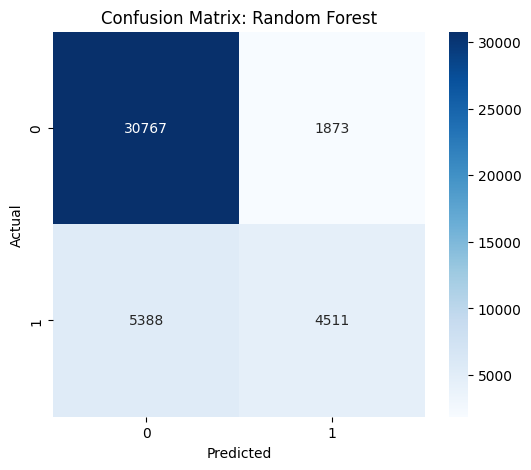

In [22]:
plt.figure(figsize=(6,5))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=[0,1], yticklabels=[0,1])
plt.title('Confusion Matrix: Random Forest')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

#### **Comparing Algorithms Performance**

In [23]:
accuracies = {
    'Logistic Regression': 0.8293095747431769,  
    'Decision Tree': 0.7119584381391194,         
    'Random Forest': 0.8261360163614565,        
    'XGBoost': 0.8282752297891347             
}

# Convert to DataFrame
acc_df = pd.DataFrame(list(accuracies.items()), columns=['Algorithm','Accuracy'])
acc_df

,Algorithm,Accuracy
0,Logistic Regression,0.829310
1,Decision Tree,0.711958
2,Random Forest,0.826136
3,XGBoost,0.828275


C:\Users\Hp\AppData\Local\Temp\ipykernel_8516\1252589415.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Algorithm', y='Accuracy', data=acc_df, palette='Spectral')


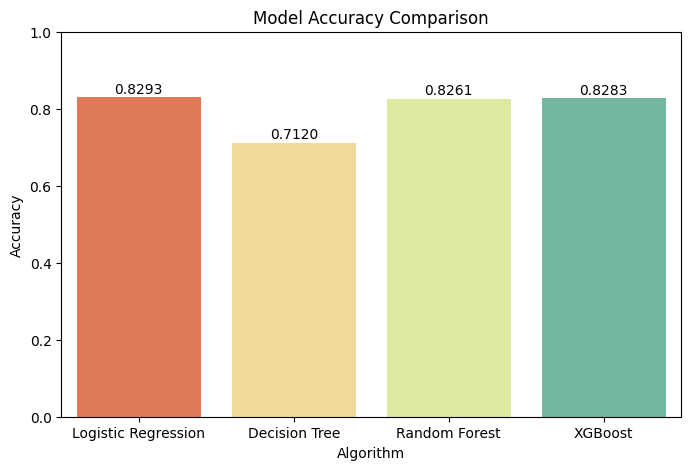

In [25]:
plt.figure(figsize=(8,5))
sns.barplot(x='Algorithm', y='Accuracy', data=acc_df, palette='Spectral')
plt.ylim(0,1)
plt.title('Model Accuracy Comparison')
plt.ylabel('Accuracy')
plt.xticks(rotation=0)

# Add accuracy values on top of bars
for index, row in acc_df.iterrows():
    plt.text(index, row.Accuracy + 0.01, f"{row.Accuracy:.4f}", ha='center')

plt.show()